In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import os, sys, time, json
from datetime import datetime

sys.path.append('..')

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

from synthetic_teacher_experiments import (
    generate_views, create_ground_truth_function, ViewStrategy
)
from src.networks import UnsharedCNNWithH, count_parameters

Device: cuda


In [14]:
def generate_data(d, K_true, N, seed, sigma=0.0):
    rng = np.random.default_rng(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    H_gt = generate_views(d, 10, ViewStrategy.DISJOINT_BLOCKS, seed=seed)
    gt_fn = create_ground_truth_function(d, K_true, H_gt, seed)

    X = torch.from_numpy(rng.standard_normal((N, d)).astype(np.float32))
    X = X / X.norm(dim=1, keepdim=True)

    with torch.no_grad():
        y_clean = gt_fn(X)

    noise = torch.from_numpy(rng.normal(0, sigma, N).astype(np.float32))
    return X, y_clean, y_clean + noise


## Training

In [15]:
def compute_generalization_gap(excess_risk, train_loss, sigma):
    return abs(excess_risk + sigma**2 - train_loss)


def train_and_eval(model, X_train, y_train, X_test, y_test_clean, config, sigma,
                   log_prefix='', log_interval=5000):
    model = model.to(DEVICE)
    X_tr, y_tr = X_train.to(DEVICE), y_train.to(DEVICE)
    X_te, y_te = X_test.to(DEVICE),  y_test_clean.to(DEVICE)

    opt = torch.optim.SGD(model.parameters(), lr=config['lr'],
                          momentum=config['momentum'],
                          weight_decay=config['weight_decay'])
    mse = nn.MSELoss()
    train_losses, excess_risks, gen_gaps = [], [], []
    t0 = time.time()

    for ep in range(config['epochs']):
        model.train()
        opt.zero_grad()
        loss = mse(model(X_tr), y_tr)
        loss.backward()
        if config['grad_clip']:
            torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
        opt.step()

        model.eval()
        with torch.no_grad():
            tl = mse(model(X_tr), y_tr).item()
            er = mse(model(X_te), y_te).item()
        gg = compute_generalization_gap(er, tl, sigma)
        train_losses.append(tl)
        excess_risks.append(er)
        gen_gaps.append(gg)

        if log_interval and (ep + 1) % log_interval == 0:
            elapsed = time.time() - t0
            print(f'    {log_prefix}ep={ep+1:>6}/{config["epochs"]}  '
                  f'train={tl:.4f}  excess={er:.4f}  gap={gg:.4f}  [{elapsed:.0f}s]')

    return {
        'train_loss'   : train_losses,
        'excess_risk'  : excess_risks,
        'gen_gap'      : gen_gaps,
        'final_gen_gap': gen_gaps[-1],
        'final_excess' : excess_risks[-1],
        'final_train'  : train_losses[-1],
    }

## Fixed L=10, Varying d and n

In [21]:
K_TRUE = 20
SIGMA  = 1.0

K_MODEL2  = 64
M_FIXED2  = 10   # patch size fixed
L_FIXED2  = 10   # number of patches fixed
D_VALUES2 = [100, 200, 300]   # d >= L*m=100; patches cover first L*m features
N_VALUES2 = [1024, 2048, 4096, 8192, 16384]
N_TEST2   = 10000
SEEDS2    = [42]
N_SEEDS2  = len(SEEDS2)

TRAIN_CONFIG2 = {
    'lr'         : 0.2,
    'momentum'   : 0.0,
    'weight_decay': 0.0,
    'grad_clip'  : 100,
    'epochs'     : 30000,
}

SAVE_DIR2 = 'figures/unshared_scn_large_n'
os.makedirs(SAVE_DIR2, exist_ok=True)

def make_fixed_patches(d, L, m, seed):
    """L disjoint patches of size m; indices shuffled by seed but always L*m features."""
    rng = np.random.default_rng(seed)
    # choose L*m feature indices without replacement, then reshape into (L, m)
    indices = rng.choice(d, size=L * m, replace=False)
    indices.sort()  # deterministic order
    return indices.reshape(L, m).astype(np.int64)

params2 = K_MODEL2 * L_FIXED2 * M_FIXED2 + K_MODEL2 + 1
print(f'Fixed: K={K_MODEL2}, L={L_FIXED2}, m={M_FIXED2}  => params={params2:,} (constant across d)')
print()
for d in D_VALUES2:
    print(f'  d={d:3d}  params={params2:,}')
    for n in N_VALUES2:
        print(f'    n={n:5d}: ratio={params2/n:.2f}x')


Fixed: K=64, L=10, m=10  => params=6,465 (constant across d)

  d=100  params=6,465
    n= 1024: ratio=6.31x
    n= 2048: ratio=3.16x
    n= 4096: ratio=1.58x
    n= 8192: ratio=0.79x
    n=16384: ratio=0.39x
  d=200  params=6,465
    n= 1024: ratio=6.31x
    n= 2048: ratio=3.16x
    n= 4096: ratio=1.58x
    n= 8192: ratio=0.79x
    n=16384: ratio=0.39x
  d=300  params=6,465
    n= 1024: ratio=6.31x
    n= 2048: ratio=3.16x
    n= 4096: ratio=1.58x
    n= 8192: ratio=0.79x
    n=16384: ratio=0.39x


### Benchmark

In [22]:
BENCH_EPOCHS2 = 100
print(f'Benchmarking {BENCH_EPOCHS2} epochs per (d, n)...\n')
print(f'{"d":>5} {"n":>6}  {"ms/epoch":>10}  {"per model":>10}')
print('-' * 40)

grand_total_sec2 = 0.0

for d in D_VALUES2:
    H = make_fixed_patches(d, L_FIXED2, M_FIXED2, seed=42)
    for n in N_VALUES2:
        np.random.seed(42); torch.manual_seed(42)
        X_all, y_clean_all, y_all = generate_data(d, K_TRUE, n + N_TEST2, 42, sigma=SIGMA)
        X_tr = X_all[:n].to(DEVICE); y_tr = y_all[:n].to(DEVICE)
        X_te = X_all[n:].to(DEVICE); y_te = y_clean_all[n:].to(DEVICE)

        torch.manual_seed(42)
        model = UnsharedCNNWithH(d, K_MODEL2, H).to(DEVICE)
        opt = torch.optim.SGD(model.parameters(), lr=TRAIN_CONFIG2['lr'])
        mse_fn = nn.MSELoss()

        t0 = time.time()
        for ep in range(BENCH_EPOCHS2):
            model.train(); opt.zero_grad()
            mse_fn(model(X_tr), y_tr).backward(); opt.step()
            model.eval()
            with torch.no_grad():
                mse_fn(model(X_tr), y_tr).item()
                mse_fn(model(X_te), y_te).item()
        elapsed = time.time() - t0

        ms_per_epoch  = elapsed / BENCH_EPOCHS2 * 1000
        per_model_sec = elapsed / BENCH_EPOCHS2 * TRAIN_CONFIG2['epochs']
        grand_total_sec2 += per_model_sec * N_SEEDS2

        def fmt(s): return f'{s/3600:.2f}h' if s >= 3600 else f'{s/60:.1f}m'
        print(f'{d:>5} {n:>6}  {ms_per_epoch:>10.1f}  {fmt(per_model_sec):>10}')

print('-' * 40)
print(f'Total estimated: {fmt(grand_total_sec2)}  ({len(D_VALUES2)}d x {len(N_VALUES2)}n x {N_SEEDS2} seed)')


Benchmarking 100 epochs per (d, n)...

    d      n    ms/epoch   per model
----------------------------------------
  100   1024         1.6        0.8m
  100   2048         1.6        0.8m
  100   4096         1.8        0.9m
  100   8192         2.7        1.3m
  100  16384         4.5        2.2m
  200   1024         1.6        0.8m
  200   2048         1.6        0.8m
  200   4096         1.9        0.9m
  200   8192         2.6        1.3m
  200  16384         4.5        2.2m
  300   1024         1.6        0.8m
  300   2048         1.6        0.8m
  300   4096         1.9        0.9m
  300   8192         2.6        1.3m
  300  16384         4.5        2.3m
----------------------------------------
Total estimated: 18.3m  (3d x 5n x 1 seed)


### Sweep

In [23]:
RESULTS_PATH2 = f'{SAVE_DIR2}/experiment_results.npz'


def save_results2(results, save_dir, config):
    data_dict = {
        'metadata': json.dumps({
            'timestamp': datetime.now().isoformat(),
            'K_MODEL': config['K_MODEL'], 'K_TRUE': config['K_TRUE'],
            'SIGMA': config['SIGMA'], 'D_VALUES': config['D_VALUES'],
            'L_FIXED': config['L_FIXED'], 'M_FIXED': config['M_FIXED'],
            'N_VALUES': config['N_VALUES'], 'SEEDS': config['SEEDS'],
            'TRAIN_CONFIG': config['TRAIN_CONFIG'],
        }),
    }
    for d in results:
        for n in results[d]:
            entry = results[d][n]
            if len(entry['gen_gaps']) > 0:
                prefix = f'd{d}_n{n}_'
                data_dict[prefix + 'gen_gaps']     = np.array(entry['gen_gaps'])
                data_dict[prefix + 'train_losses'] = np.array(entry['train_losses'])
                data_dict[prefix + 'excess_risks'] = np.array(entry['excess_risks'])
    np.savez(save_dir + '/experiment_results.npz', **data_dict)


def load_results2(filepath):
    data = np.load(filepath, allow_pickle=True)
    meta = json.loads(str(data['metadata']))
    print(f"Loaded: {meta['timestamp']}")
    print(f"  K={meta['K_MODEL']}, L={meta['L_FIXED']}, m={meta['M_FIXED']}, seeds={meta['SEEDS']}")
    D = meta['D_VALUES']; N = meta['N_VALUES']
    results = {d: {n: {'gen_gaps': [], 'train_losses': [], 'excess_risks': []} for n in N} for d in D}
    for d in D:
        for n in N:
            prefix = f'd{d}_n{n}_'
            if prefix + 'gen_gaps' in data:
                results[d][n]['gen_gaps']     = list(data[prefix + 'gen_gaps'])
                results[d][n]['train_losses'] = list(data[prefix + 'train_losses'])
                results[d][n]['excess_risks'] = list(data[prefix + 'excess_risks'])
    return results, meta


if os.path.exists(RESULTS_PATH2):
    results2, _ = load_results2(RESULTS_PATH2)
else:
    results2 = {d: {n: {'gen_gaps': [], 'train_losses': [], 'excess_risks': []} for n in N_VALUES2} for d in D_VALUES2}

exp_config2 = dict(K_MODEL=K_MODEL2, K_TRUE=K_TRUE, SIGMA=SIGMA,
                   D_VALUES=D_VALUES2, L_FIXED=L_FIXED2, M_FIXED=M_FIXED2,
                   N_VALUES=N_VALUES2, SEEDS=list(SEEDS2),
                   TRAIN_CONFIG=TRAIN_CONFIG2)

sweep_t0 = time.time()

for d in D_VALUES2:
    print(f'\n{"="*55}\nd={d}  L={L_FIXED2}  m={M_FIXED2}\n{"="*55}')

    for n in N_VALUES2:
        existing = len(results2[d][n]['gen_gaps'])
        if existing >= N_SEEDS2:
            gaps = results2[d][n]['gen_gaps']
            print(f'  n={n:5d}  [cached]  gap={np.mean(gaps):.4f}')
            continue

        n_t0 = time.time()
        print(f'  n={n}  (resuming from seed {existing+1}/{N_SEEDS2})')

        for seed_idx, seed in enumerate(SEEDS2):
            if seed_idx < existing:
                continue

            H = make_fixed_patches(d, L_FIXED2, M_FIXED2, seed=seed)
            X_all, y_clean_all, y_all = generate_data(d, K_TRUE, n + N_TEST2, seed, sigma=SIGMA)
            X_train, y_train = X_all[:n], y_all[:n]
            X_test,  y_test  = X_all[n:], y_clean_all[n:]

            torch.manual_seed(seed)
            model = UnsharedCNNWithH(d, K_MODEL2, H)

            seed_t0 = time.time()
            print(f'    -> seed={seed} ({seed_idx+1}/{N_SEEDS2})')
            hist = train_and_eval(model, X_train, y_train, X_test, y_test,
                                  TRAIN_CONFIG2, SIGMA,
                                  log_prefix=f'd={d} n={n} seed={seed}  ')
            results2[d][n]['gen_gaps'].append(hist['final_gen_gap'])
            results2[d][n]['train_losses'].append(hist['final_train'])
            results2[d][n]['excess_risks'].append(hist['final_excess'])
            print(f'    -> seed={seed} done  gap={hist["final_gen_gap"]:.4f}  [{time.time()-seed_t0:.0f}s]')
            save_results2(results2, SAVE_DIR2, exp_config2)

        gaps = results2[d][n]['gen_gaps']
        print(f'  n={n:5d}  gap={np.mean(gaps):.4f} +/- {np.std(gaps):.4f}  total={time.time()-n_t0:.0f}s')

print(f'\nDone. Total: {(time.time()-sweep_t0)/60:.1f} min')



d=100  L=10  m=10
  n=1024  (resuming from seed 1/1)
    -> seed=42 (1/1)
    d=100 n=1024 seed=42  ep=  5000/30000  train=0.8206  excess=0.1761  gap=0.3555  [9s]
    d=100 n=1024 seed=42  ep= 10000/30000  train=0.6156  excess=0.3772  gap=0.7615  [18s]
    d=100 n=1024 seed=42  ep= 15000/30000  train=0.4708  excess=0.5468  gap=1.0760  [28s]
    d=100 n=1024 seed=42  ep= 20000/30000  train=0.3725  excess=0.6562  gap=1.2837  [37s]
    d=100 n=1024 seed=42  ep= 25000/30000  train=0.2978  excess=0.7376  gap=1.4398  [46s]
    d=100 n=1024 seed=42  ep= 30000/30000  train=0.2442  excess=0.8028  gap=1.5586  [55s]
    -> seed=42 done  gap=1.5586  [55s]
  n= 1024  gap=1.5586 +/- 0.0000  total=55s
  n=2048  (resuming from seed 1/1)
    -> seed=42 (1/1)
    d=100 n=2048 seed=42  ep=  5000/30000  train=0.8590  excess=0.0640  gap=0.2050  [9s]
    d=100 n=2048 seed=42  ep= 10000/30000  train=0.7818  excess=0.1336  gap=0.3518  [18s]
    d=100 n=2048 seed=42  ep= 15000/30000  train=0.6848  excess=0.24

In [24]:
# Load results (run this to skip sweep)
# results2, _meta2 = load_results2(f'{SAVE_DIR2}/experiment_results.npz')


### Plot: log(Gap) vs log(n)

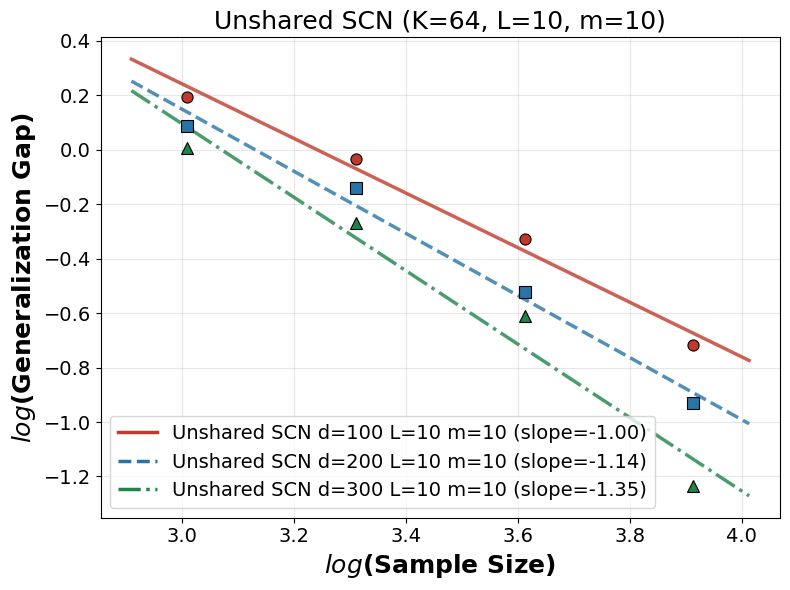

In [28]:
LABEL_SIZE = 18; TICK_SIZE = 14; TITLE_SIZE = 18; LW = 2.5; LEGEND_SIZE = 14
D_COLORS_DARK = ['#C0392B', '#2874A6', '#1E8449']
D_MARKERS     = ['o', 's', '^']
D_LINESTYLES  = ['-', '--', '-.']

fig, ax = plt.subplots(figsize=(8, 6))
N_PLOT2 = [n for n in N_VALUES2 if n != 16384]
n_arr = np.array(N_PLOT2)
log_n = np.log10(n_arr)

legend_handles = []; legend_labels = []

for d_idx, d in enumerate(D_VALUES2):
    color  = D_COLORS_DARK[d_idx]
    marker = D_MARKERS[d_idx]
    ls     = D_LINESTYLES[d_idx]

    means = np.array([np.mean(results2[d][n]['gen_gaps']) for n in N_PLOT2])
    stds  = np.array([np.std(results2[d][n]['gen_gaps'])  for n in N_PLOT2])

    log_mean = np.log10(np.maximum(means, 1e-6))
    log_err  = stds / (np.maximum(means, 1e-6) * np.log(10))

    valid = means > 1e-6
    slope = float('nan')
    if valid.sum() >= 2:
        slope, intercept, _, _, _ = stats.linregress(log_n[valid], log_mean[valid])
        n_fit = np.array([log_n[valid].min() - 0.1, log_n[valid].max() + 0.1])
        ax.plot(n_fit, slope * n_fit + intercept, linestyle=ls, color=color, linewidth=LW, alpha=0.8)

    ax.errorbar(log_n, log_mean, yerr=log_err, fmt=marker, color=color,
                markersize=8, markeredgecolor='black', markeredgewidth=0.8,
                capsize=0, elinewidth=2)

    legend_handles.append(Line2D([0], [0], color=color, linewidth=LW, linestyle=ls))
    legend_labels.append(f'Unshared SCN d={d} L={L_FIXED2} m={M_FIXED2} (slope={slope:.2f})')

ax.set_xlabel('$log$(Sample Size)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('$log$(Generalization Gap)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Unshared SCN (K={K_MODEL2}, L={L_FIXED2}, m={M_FIXED2})', fontsize=TITLE_SIZE)
ax.legend(legend_handles, legend_labels, loc='lower left', fontsize=LEGEND_SIZE)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=TICK_SIZE)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR2}/unshared_large_n_gap_vs_n.pdf', dpi=300, bbox_inches='tight')
plt.show()


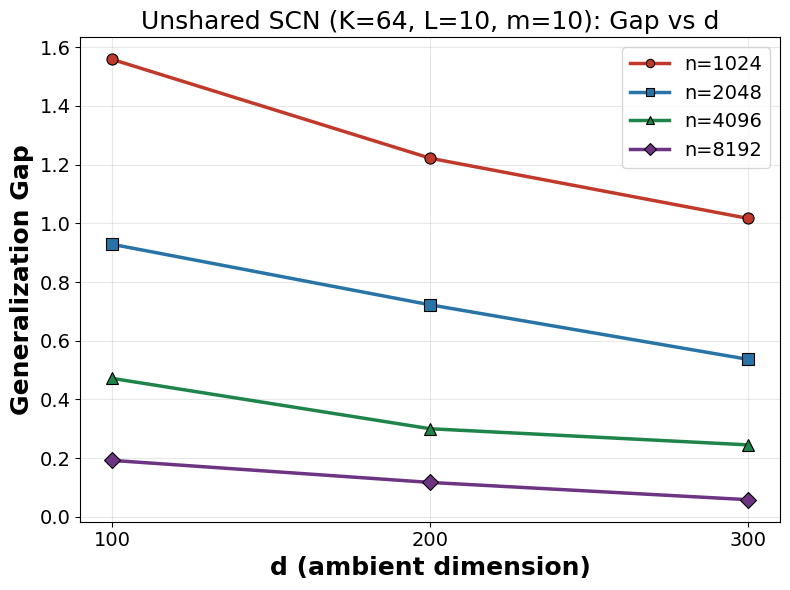

In [29]:
# Plot: gen gap vs d at fixed n values
N_PLOT = [1024, 2048, 4096, 8192]
N_COLORS = ['#C0392B', '#2874A6', '#1E8449', '#6C3483', '#B9770E']
N_MARKERS = ['o', 's', '^', 'D', 'v']

fig, ax = plt.subplots(figsize=(8, 6))
d_arr = np.array(D_VALUES2)

legend_handles = []; legend_labels = []

for n_idx, n in enumerate(N_PLOT):
    color  = N_COLORS[n_idx]
    marker = N_MARKERS[n_idx]
    gaps   = np.array([np.mean(results2[d][n]['gen_gaps']) for d in D_VALUES2])
    ax.plot(d_arr, gaps, marker=marker, color=color, linewidth=LW,
            markersize=8, markeredgecolor='black', markeredgewidth=0.8)
    legend_handles.append(Line2D([0], [0], color=color, linewidth=LW, marker=marker,
                                  markeredgecolor='black', markeredgewidth=0.8))
    legend_labels.append(f'n={n}')

ax.set_xlabel('d (ambient dimension)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Generalization Gap', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Unshared SCN (K={K_MODEL2}, L={L_FIXED2}, m={M_FIXED2}): Gap vs d', fontsize=TITLE_SIZE)
ax.set_xticks(d_arr)
ax.legend(legend_handles, legend_labels, loc='upper right', fontsize=LEGEND_SIZE)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=TICK_SIZE)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR2}/unshared_large_n_gap_vs_d.pdf', dpi=300, bbox_inches='tight')
plt.show()
